In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d psraju2024/alzheimers-dataset-4-class-of-images


!unzip -q alzheimers-dataset-4-class-of-images.zip -d dataset

print("Veriler başarıyla indirildi!")

Dataset URL: https://www.kaggle.com/datasets/psraju2024/alzheimers-dataset-4-class-of-images
License(s): unknown
100% 34.1M/34.1M [00:00<00:00, 90.6MB/s]

 linkten veriler başarıyla indirildi!


In [ ]:
import os

print(" Zipten Çıkan Klasör Yapısı:\n")
for root, dirs, files in os.walk('dataset'):
    # Sadece içinde resim olan klasörleri ekrana basıyoruz
    if len(files) > 0:
        print(f"Bulunan Yol: {root} ---> İçinde {len(files)} adet dosya var.")

📂 Zipten Çıkan Klasör Yapısı:

Bulunan Yol: dataset/Alzheimer_MRI_4_classes_dataset/NonDemented ---> İçinde 3200 adet dosya var.
Bulunan Yol: dataset/Alzheimer_MRI_4_classes_dataset/ModerateDemented ---> İçinde 64 adet dosya var.
Bulunan Yol: dataset/Alzheimer_MRI_4_classes_dataset/MildDemented ---> İçinde 896 adet dosya var.
Bulunan Yol: dataset/Alzheimer_MRI_4_classes_dataset/VeryMildDemented ---> İçinde 2240 adet dosya var.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Röntgen sonucunda bulduğumuz GERÇEK ana klasör yolumuz
base_dir = 'dataset/Alzheimer_MRI_4_classes_dataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("---  VERİ ÇOĞALTMA VE OTOMATİK BÖLME BAŞLIYOR ---")

# 1. EĞİTİM VERİSİ İÇİN (Hem çoğaltıyoruz, hem %80'ini alıyoruz)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Verinin %20'sini teste ayır
)

# 2. TEST VERİSİ İÇİN (Sadece %20'yi alıyoruz, ASLA çoğaltmıyoruz/değiştirmiyoruz)
test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Aynı oranı buraya da veriyoruz
)

print("Eğitim Verisi (Train) Yükleniyor...")
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',     # %80'lik kısmı al
    seed=42,               # Aynı resimlerin train/test'e karışmaması için şifre
    shuffle=True
)

print("\nTest/Doğrulama Verisi (Validation) Yükleniyor...")
test_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',   # %20'lik test kısmını al
    seed=42,
    shuffle=False          # Test verisi KARIŞTIRILMAZ
)

print("\n Operasyon Başarılı! Veriler Eğitime Hazır.")
print("Sınıflarımız:", list(train_generator.class_indices.keys()))

--- 🔄 VERİ ÇOĞALTMA VE OTOMATİK BÖLME BAŞLIYOR ---
Eğitim Verisi (Train) Yükleniyor...
Found 5121 images belonging to 4 classes.

Test/Doğrulama Verisi (Validation) Yükleniyor...
Found 1279 images belonging to 4 classes.

✅ Operasyon Başarılı! Veriler Eğitime Hazır.
Sınıflarımız: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
import pandas as pd

print("---  EFFICIENTNET-B3 BEYNİ İNŞA EDİLİYOR ---")

# 1. Temel Modeli İndir (Google'ın devasa beyni)
base_model = EfficientNetB3(
    weights='imagenet',       # ImageNet tecrübesini kullan
    include_top=False,        # Orijinal sınıflandırıcıyı kesip atıyoruz
    input_shape=(224, 224, 3) # Bizim resim boyutumuz
)

# Temel modelin önceden öğrendiklerini unutmaması için ağırlıkları donduruyoruz
base_model.trainable = False

# 2. Kendi Sınıflandırma Katmanlarımızı Ekleme
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),          # Özellikleri düzleştir
    layers.BatchNormalization(),              # Ağı hızlandır ve dengede tut
    layers.Dense(512, activation='relu'),     # Kendi karar nöronlarımız
    layers.Dropout(0.5),                      # Ezberlemeyi önle (Overfitting kalkanı)
    layers.Dense(4, activation='softmax')     # 4 Alzheimer Evresi için sonuç katmanı
])

# 3. Modeli Derleme (Öğrenme hızı ve Hata fonksiyonu)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. AKILLI EĞİTİM ASİSTANLARI (Callbacks)
# a) Erken Durdurma: Model 5 adım boyunca gelişmezse eğitimi kesip en iyi hali geri yükler
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# b) Vites Küçültme: Model takılırsa öğrenme hızını düşürür (Daha ince detayları öğrenir)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)

# c) Checkpoint: Her epoch'ta gelişme varsa modeli Drive'a kaydet (Colab çökse bile kurtarırız)
model_save_path = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model.keras'
checkpoint = callbacks.ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, verbose=1)

print("\n--- 🚀 EĞİTİM BAŞLIYOR (T4 GPU DEVREDE) ---")
# 15 Epoch (Döngü) yeterli olacaktır.
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Eğitim geçmişini kaydet (Bir sonraki adımda grafik çizmek için lazım)
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/egitim_gecmisi.csv', index=False)

print("\n EĞİTİM TAMAMLANDI! Model ve eğitim verileri başarıyla Drive'a kaydedildi.")

--- 🧠 EFFICIENTNET-B3 BEYNİ İNŞA EDİLİYOR ---
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- 🚀 EĞİTİM BAŞLIYOR (T4 GPU DEVREDE) ---
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.4021 - loss: 1.9158
Epoch 1: val_accuracy improved from None to 0.50586, saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 167s 750ms/step - accuracy: 0.4089 - loss: 1.7678 - val_accuracy: 0.5059 - val_loss: 1.2440 - learning_rate: 0.0010
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.4395 - loss: 1.3890
Epoch 2: val_accuracy did not improve from 0.50586
161/161 ━━━━━━━━━━━━━━━━━━━━ 66s 406ms/step - accuracy: 0.4341 - loss: 1.3377 - val_accuracy: 0.5004 - val_loss: 1.2916 - learning_rate: 0.0010
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step

In [ ]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks

print("---  FINE-TUNING VE SINIF AĞIRLIKLARI DEVREYE GİRİYOR ---")

# 1. SINIF AĞIRLIKLARINI HESAPLAMA (Az olan resmi değerli kılma)
y_train = train_generator.classes
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_array))

print(" Modelin Yeni Odaklanma Ağırlıkları (Az olan çok değerli):")
for idx, weight in class_weights_dict.items():
    print(f"{list(train_generator.class_indices.keys())[idx]}: {weight:.2f}x Ceza Puanı")

# 2. ZİNCİRLERİ KIRMA (Unfreezing)
# Temel modelin kilidini tamamen açıyoruz
base_model.trainable = True

# Ama temel şekilleri (çizgi, kenar) öğrenen ilk katmanları koruyoruz.
# Sadece ağın son 30 katmanını eğitime açıyoruz ki beyin MR'ının detaylarını ezberlesin.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. YENİDEN DERLEME (Çok daha düşük bir öğrenme hızı ile)
model.compile(
    optimizer=Adam(learning_rate=1e-4), # Mikro öğrenme hızı (İnce işçilik)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. KAYDETME AYARLARI (Yol kesinlikle Ileri_Derin_Ogrenme_Projesi)
model_save_path_ft = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model_finetuned.keras'
checkpoint_ft = callbacks.ModelCheckpoint(model_save_path_ft, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop_ft = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

print("\n---  İKİNCİ AŞAMA EĞİTİM (FINE-TUNING) BAŞLIYOR ---")
# 15 Epoch daha eğitiyoruz ama bu sefer kurallar bizim kurallarımız!
history_ft = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    class_weight=class_weights_dict, # Sihirli ağırlıklar modele veriliyor
    callbacks=[checkpoint_ft, early_stop_ft]
)

print("\n FINE-TUNING TAMAMLANDI!")

--- 🔓 FINE-TUNING VE SINIF AĞIRLIKLARI (HİLE KODU) DEVREYE GİRİYOR ---
🎯 Modelin Yeni Odaklanma Ağırlıkları (Az olan çok değerli):
MildDemented: 1.79x Ceza Puanı
ModerateDemented: 24.62x Ceza Puanı
NonDemented: 0.50x Ceza Puanı
VeryMildDemented: 0.71x Ceza Puanı

--- 🚀 İKİNCİ AŞAMA EĞİTİM (FINE-TUNING) BAŞLIYOR ---
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.3092 - loss: 1.6163
Epoch 1: val_accuracy improved from None to 0.17201, saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/en_iyi_model_finetuned.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 151s 674ms/step - accuracy: 0.2798 - loss: 1.6952 - val_accuracy: 0.1720 - val_loss: 1.3835
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.2320 - loss: 1.6107
Epoch 2: val_accuracy improved from 0.17201 to 0.50195, saving model to /con

In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models, callbacks, optimizers
import tensorflow as tf

print("--- MODEL KURULUMU ---")

# 1. TEMEL MODEL (EfficientNetB3) - Tamamen açık (Fine-tuning için hazır)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True # Tüm katmanları en baştan eğitime açıyoruz!

# 2. MODEL MİMARİSİ (Daha derin ve daha dirençli)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='swish'), # Daha modern bir aktivasyon fonksiyonu
    layers.Dropout(0.5),
    layers.Dense(512, activation='swish'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

# 3. ÖĞRENME HIZI VE OPTİMİZASYON
# Başta hızlı başlayıp, hata payı azaldıkça yavaşlayan sistem
initial_lr = 1e-4
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_lr, decay_steps=1000, decay_rate=0.9, staircase=True)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # %90 için anahtar hamle
    metrics=['accuracy']
)

# 4. CALLBACKS
model_save_path_top = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras'
checkpoint = callbacks.ModelCheckpoint(model_save_path_top, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


history_top = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[checkpoint, early_stop]
)

print("\n OPERASYON BİTTİ.")

--- MODEL KURULUMU ---
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.3443 - loss: 1.7169
Epoch 1: val_accuracy improved from None to 0.00938, saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.3794 - loss: 1.4811 - val_accuracy: 0.0094 - val_loss: 1.6798
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.4482 - loss: 1.1979
Epoch 2: val_accuracy improved from 0.00938 to 0.31587, saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 85s 526ms/step - accuracy: 0.4675 -

In [1]:
# 1. Drive Bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# 2. Veriyi Kaggle'dan Çekme
!kaggle datasets download -d psraju2024/alzheimers-dataset-4-class-of-images
!unzip -q alzheimers-dataset-4-class-of-images.zip -d dataset

print(" Veriler hazır!")

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/psraju2024/alzheimers-dataset-4-class-of-images
License(s): unknown
100% 34.1M/34.1M [00:00<00:00, 106MB/s] 

 Veriler hazır!


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ayarlarımız (B3 için 224x224 ideal)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
base_dir = 'dataset/Alzheimer_MRI_4_classes_dataset'

# VERİ ÇOĞALTMA
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Daha fazla döndürme
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,         # Beyin MR'ındaki küçük küçülmeleri yakalamak için zoom
    horizontal_flip=True,
    brightness_range=[0.8, 1.2], # Işık farklarını dengele
    fill_mode='nearest',
    validation_split=0.2    # %20 test payı
)

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

print("---  AKILLI VERİ YÜKLEYİCİLER ÇALIŞTIRILIYOR ---")

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

--- 🔄 AKILLI VERİ YÜKLEYİCİLER ÇALIŞTIRILIYOR ---
Found 5121 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [3]:
from tensorflow.keras.models import load_model

# En son hangi isimle kaydettiysen onu kullan (Genelde top_performance_model.keras)
model_yolu = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model.keras'

try:
    model = load_model(model_yolu)
    print("✅ En iyi model başarıyla yüklendi! Kaldığımız yerden tırmanışa geçiyoruz.")
except:
    print("❌ Model dosyası bulunamadı, yeni mimariyi kurmam gerekecek. Bana haber ver!")

✅ En iyi model başarıyla yüklendi! Kaldığımız yerden tırmanışa geçiyoruz.


In [4]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau

print("--- TAM KATMAN EĞİTİMİ BAŞLIYOR ---")

# 1. Modelin tamamını eğitime açıyoruz
model.trainable = True

# 2. Öğrenme hızını "mikro" seviyeye çekiyoruz (İnce işçilik modu)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Callbacks Ayarları (Drive yollarını kontrol et!)
base_path = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/'

checkpoint = ModelCheckpoint(
    base_path + 'top_performance_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Drive'daki CSV'yi güncel tutacak olan komut
log_csv = CSVLogger(base_path + 'egitim_gecmisi_final.csv', append=True)

# Model tıkanırsa vitesi biraz daha küçült
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# 4. Eğitim Başlıyor
history_final = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15, # Zaten iyi bir noktadayız, 15 epoch cilalamaya yeter
    callbacks=[checkpoint, log_csv, reduce_lr, early_stop]
)

print("\n Eğitim bitti! Drive'daki 'egitim_gecmisi_final.csv' dosyasını kontrol edebilirsin.")

--- 🚨 FİNAL OPERASYONU: TAM KATMAN EĞİTİMİ BAŞLIYOR ---
Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8209 - loss: 0.4762
Epoch 1: val_accuracy improved from None to 0.34480, saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/top_performance_model_v2.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.8239 - loss: 0.4623 - val_accuracy: 0.3448 - val_loss: 1.5857 - learning_rate: 1.0000e-05
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8338 - loss: 0.4278
Epoch 2: val_accuracy did not improve from 0.34480
161/161 ━━━━━━━━━━━━━━━━━━━━ 100s 621ms/step - accuracy: 0.8389 - loss: 0.4174 - val_accuracy: 0.3417 - val_loss: 1.3777 - learning_rate: 1.0000e-05
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.8537 - loss: 0.3891
Epoch 3: val_accuracy i

--- 🧠 MODEL YÜKLENİYOR VE ANALİZ BAŞLIYOR ---
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 358ms/step

📝 DETAYLI METRİK RAPORU:
                  precision    recall  f1-score   support

    MildDemented       0.89      0.79      0.84       179
ModerateDemented       1.00      0.92      0.96        12
     NonDemented       0.85      0.93      0.89       640
VeryMildDemented       0.85      0.78      0.81       448

        accuracy                           0.86      1279
       macro avg       0.90      0.85      0.87      1279
    weighted avg       0.86      0.86      0.86      1279



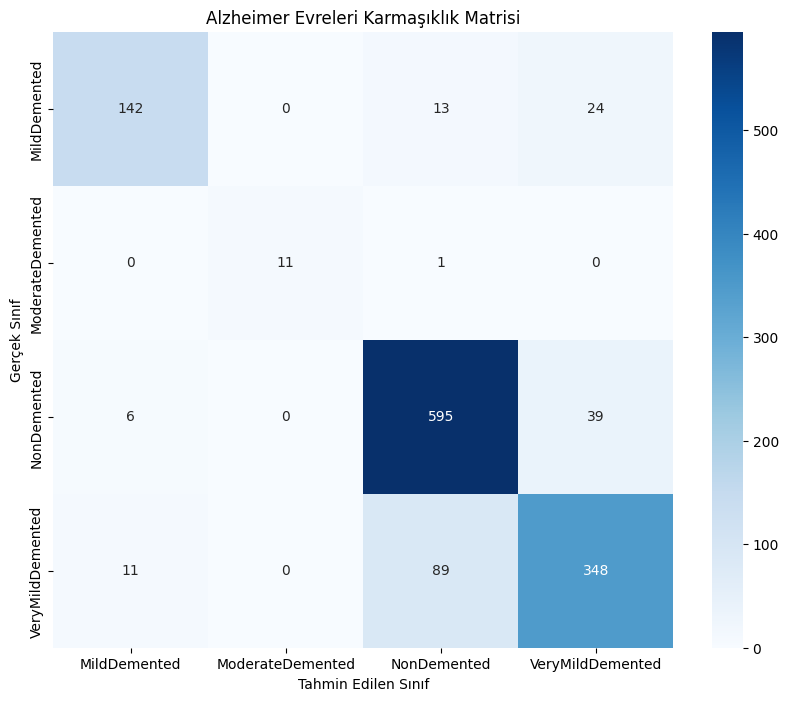

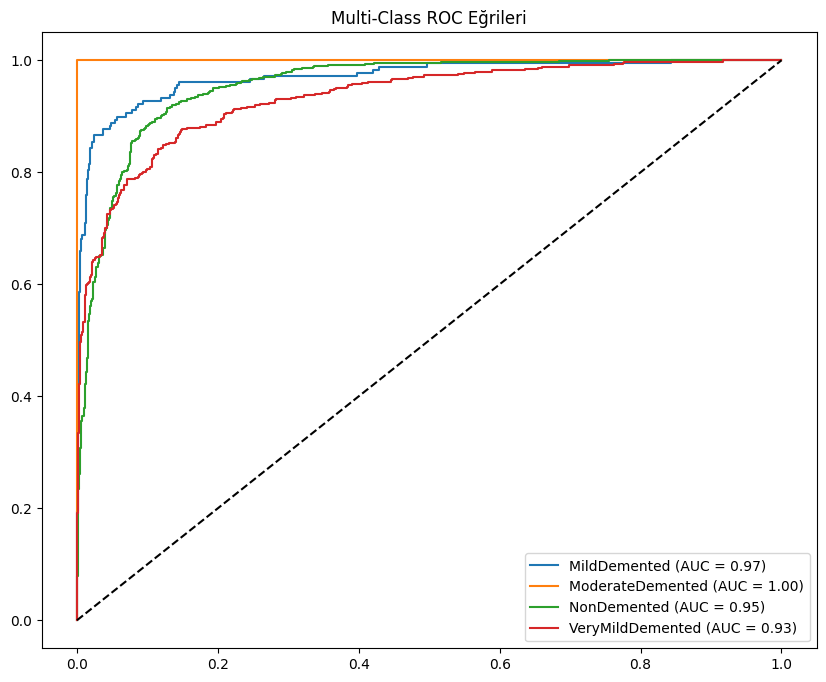

ValueError: No such layer: top_activation. Existing layers are: ['efficientnetb3', 'global_average_pooling2d_1', 'batch_normalization_1', 'dense_2', 'dropout_1', 'dense_3', 'dropout_2', 'dense_4'].

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. YOLLARI TANIMLA VE MODELİ YÜKLE
SAVE_PATH = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/'
MODEL_NAME = 'top_performance_model_v2.keras'

print("---  MODEL YÜKLENİYOR VE ANALİZ BAŞLIYOR ---")
final_model = tf.keras.models.load_model(SAVE_PATH + MODEL_NAME)

# 2. TAHMİNLERİ AL (Validation set üzerinden)
val_generator.reset()
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())
y_pred_probs = final_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. SINIFLANDIRMA RAPORU (F1-Score, Recall vb.)
print("\n DETAYLI METRİK RAPORU:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. KARMAŞIKLIK MATRİSİ (Isı Haritası)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Alzheimer Evreleri Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.savefig(SAVE_PATH + 'final_matrix.png')
plt.show()

# 5. ROC-AUC EĞRİLERİ (Tıbbi Başarı Kanıtı)
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multi-Class ROC Eğrileri')
plt.legend()
plt.savefig(SAVE_PATH + 'final_roc.png')
plt.show()

# 6. GRAD-CAM: MODELİN ODAK NOKTASI (Açıklanabilir AI)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Bir test görüntüsü üzerinde Grad-CAM denemesi
img, label = next(val_generator)
heatmap = make_gradcam_heatmap(img[0:1], final_model, 'top_activation')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img[0])
plt.title('Orijinal MR Görüntüsü')
plt.subplot(1, 2, 2)
plt.imshow(img[0])
plt.imshow(cv2.resize(heatmap, (224, 224)), alpha=0.5, cmap='jet')
plt.title('Grad-CAM (Odak Bölgeleri)')
plt.savefig(SAVE_PATH + 'grad_cam_ornek.png')
plt.show()

print(f"\n Tüm görseller Drive'a kaydedildi: {SAVE_PATH}")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

print("--- 🔍 GRAD-CAM RÖNTGENİ ÇEKİLİYOR ---")

def make_gradcam_heatmap_fixed(img_array, model, pred_index=None):
    # İÇ İÇE MODEL ÇÖZÜMÜ:
    # model.layers[0] bizim o devasa EfficientNetB3 beynimiz.
    # Onun çıkışını doğrudan ısı haritası için kullanıyoruz.
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.layers[0].output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Isı haritasını 0-1 arasına normalize et
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Rastgele bir test görüntüsü alıyoruz
img, label = next(val_generator) # test_generator yerine val_generator kullanıyoruz

# Düzeltilmiş fonksiyonu çağırıyoruz
heatmap = make_gradcam_heatmap_fixed(img[0:1], final_model)

# Görselleştirme
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img[0])
plt.title('Orijinal MR Görüntüsü', fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img[0])
# Jet renk paletiyle (kırmızı odaklı) ısı haritasını MR'ın üzerine giydiriyoruz
plt.imshow(cv2.resize(heatmap, (224, 224)), alpha=0.5, cmap='jet')
plt.title('Grad-CAM: Yapay Zeka Nereye Bakıyor?', fontweight='bold')
plt.axis('off')

# Drive'a kaydet
SAVE_PATH = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/'
plt.savefig(SAVE_PATH + 'grad_cam_final.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n Grad-CAM Şov Görseli Drive'a kilitlendi: {SAVE_PATH}grad_cam_final.png")

--- 🔍 GRAD-CAM RÖNTGENİ ÇEKİLİYOR ---


AttributeError: The layer sequential_1 has never been called and thus has no defined output.

--- 🛠️ GRAD-CAM KESİN ÇÖZÜM (EAGER MODE) DEVREYE GİRİYOR ---


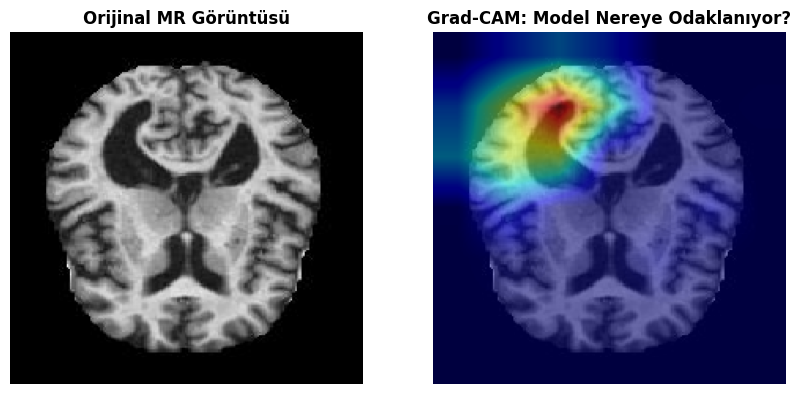


✅ Grad-CAM Şov Görseli Drive'a kilitlendi: /content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/grad_cam_final.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

print("--- 🛠️ GRAD-CAM KESİN ÇÖZÜM (EAGER MODE) DEVREYE GİRİYOR ---")

def make_gradcam_heatmap_bulletproof(img_array, model):
    # 1. İlk kutu: Sadece görüntüden özellik çıkaran EfficientNet (Base Model)
    base_model = model.layers[0]

    with tf.GradientTape() as tape:
        # Görüntüyü base_model'den geçir ve o boyut küçültülmüş özellik haritasını al
        conv_outputs = base_model(img_array, training=False)

        # Python'a "Bu veriyi takip et, üzerinden türev alacağız" diyoruz
        tape.watch(conv_outputs)

        # 2. Özellik haritasını sonraki karar katmanlarından (GlobalPooling, Dense vb.) sırayla geçiriyoruz
        x = conv_outputs
        for layer in model.layers[1:]:
            x = layer(x, training=False)
        preds = x # Final tahmin sonucu

        # En yüksek ihtimali olan sınıfı seç
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Tahminin, o haritadaki piksellere göre türevini (gradyan) alıyoruz
    grads = tape.gradient(class_channel, conv_outputs)

    # 4. Gradyanların ortalamasını alıp asıl ısı haritasını oluşturuyoruz
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Görselliği bozacak negatif değerleri sıfırla (ReLU mantığı) ve 0-1 arasına çek
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# Test setinden rastgele bir MR görüntüsü alıyoruz
img, label = next(val_generator)

# fonksiyonumuzu çağırıyoruz
heatmap = make_gradcam_heatmap_bulletproof(img[0:1], final_model)

# Görselleştirme
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img[0])
plt.title('Orijinal MR Görüntüsü', fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img[0])
# Jet renk paletiyle ısı haritasını MR'ın üzerine giydiriyoruz
plt.imshow(cv2.resize(heatmap, (224, 224)), alpha=0.5, cmap='jet')
plt.title('Grad-CAM: Model Nereye Odaklanıyor?', fontweight='bold')
plt.axis('off')

# Drive'a kaydet
SAVE_PATH = '/content/drive/MyDrive/Ileri_Derin_Ogrenme_Projesi/Alzheimer_EfficientNet/'
plt.savefig(SAVE_PATH + 'grad_cam_final.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n Grad-CAM Şov Görseli Drive'a kilitlendi: {SAVE_PATH}grad_cam_final.png")